# EDA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.eda import load_data, validate_data, get_categorical_and_numerical_features
from src.eda import get_minutes_stats, get_call_stats, get_charge_stats, get_divided_data, get_churn_rate
from src.eda import get_churned_customers, get_stayed_customers, describe_total_day_minutes, describe_international_calls
from src.eda import get_account_length_info
from utils.eda import describe_stats
from src.visualization import plot_states, plot_call_minutes, plot_call_counts
from src.visualization import plot_charge_distributions, plot_correlation, plot_churn_rate_by_customer_service_calls
from src.visualization import plot_state_churn_rates

In [2]:
df = load_data()
df

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,no,no,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,no,yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,no,no,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,no,no,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   state                   2666 non-null   category
 1   account_length          2666 non-null   int64   
 2   area_code               2666 non-null   category
 3   international_plan      2666 non-null   category
 4   voice_mail_plan         2666 non-null   category
 5   number_vmail_messages   2666 non-null   int64   
 6   total_day_minutes       2666 non-null   float64 
 7   total_day_calls         2666 non-null   int64   
 8   total_day_charge        2666 non-null   float64 
 9   total_eve_minutes       2666 non-null   float64 
 10  total_eve_calls         2666 non-null   int64   
 11  total_eve_charge        2666 non-null   float64 
 12  total_night_minutes     2666 non-null   float64 
 13  total_night_calls       2666 non-null   int64   
 14  total_night_charge      2666 non-nu

In [4]:
validate_data(df)

'Data is valid'

In [5]:
def null_values(df):
	n_nulls = df.isnull().sum().sum() # number of null values
	print(f"Dataset contains {n_nulls} null values.")

null_values(df)

Dataset contains 0 null values.


In [6]:
def get_duplicates(df):
	n_exact_dups = df.duplicated().sum() # duplicate rows
	print(f"Dataset contains {n_exact_dups} exact duplicates")

get_duplicates(df)

Dataset contains 0 exact duplicates


We are dealing with a imbalanced dataset, so we need to do some data understanding to understand the data better.

In [7]:
df['churn'].value_counts() # churn imbalance

churn
False    2278
True      388
Name: count, dtype: int64

In [8]:
def get_total_churn(df):
	total_churn = get_churn_rate({"dataset": df})
	print(f"Total Churn Rate of the Company: {total_churn['dataset']:.2f}%")

get_total_churn(df)

Total Churn Rate of the Company: 14.55%


In [9]:
categorical_features, numerical_features = get_categorical_and_numerical_features(df)

print(f"Categorical features: {categorical_features}")
print("--" * 50)
print(f"Numerical features: {numerical_features}")
print("--" * 50)
print(f"Number of categorical features: {len(categorical_features)}")
print(f"Number of numerical features: {len(numerical_features)}")

Categorical features: ['state', 'area_code', 'international_plan', 'voice_mail_plan', 'churn']
----------------------------------------------------------------------------------------------------
Numerical features: ['account_length', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'customer_service_calls']
----------------------------------------------------------------------------------------------------
Number of categorical features: 5
Number of numerical features: 15


## Univariate Analysis

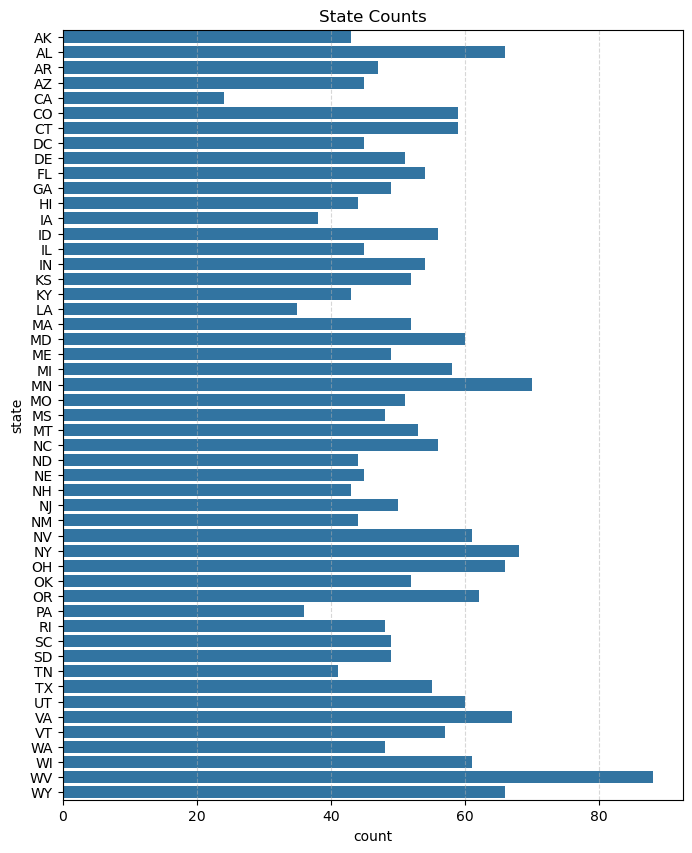

In [10]:
plot_states(df)

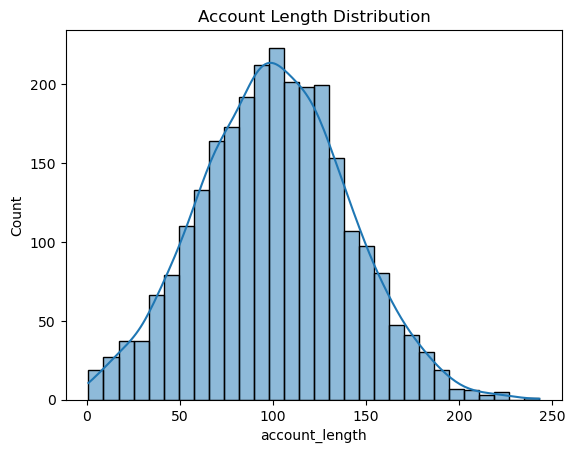

,Value
Statistic,
Count,"2,666.000"
Missing,0.000
Unique,205.000
Mean,100.620
Median,100.000
Std. Dev.,39.564
Variance,"1,565.308"
Min,1.000
Q1 (25%),73.000


In [11]:
sns.histplot(
    data=df,
    x="account_length",
    bins=30,
    kde=True,
)

plt.title("Account Length Distribution")
plt.show()

describe_stats(
    df=df,
    feature="account_length"
)

In [12]:
df['area_code'].value_counts() / df.shape[0] * 100

area_code
415    49.437359
510    25.468867
408    25.093773
Name: count, dtype: float64

In [13]:
df['international_plan'].value_counts() / df.shape[0] * 100

international_plan
no     89.872468
yes    10.127532
Name: count, dtype: float64

In [14]:
df['voice_mail_plan'].value_counts() / df.shape[0] * 100

voice_mail_plan
no     72.505626
yes    27.494374
Name: count, dtype: float64

**number_vmail_messages is a highly right skewed variable**, Maybe we should consider using a log transformation to make it more normal.

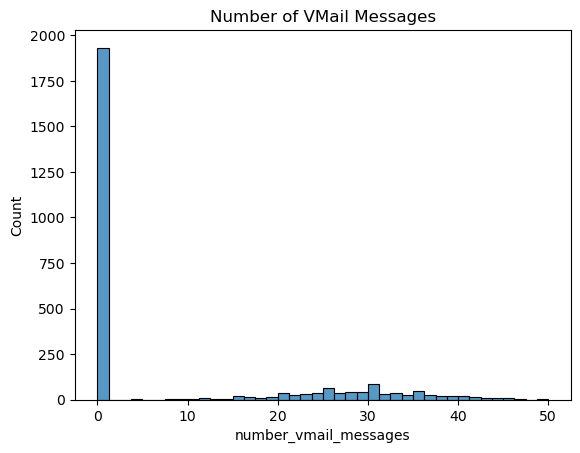

,Value
Statistic,
Count,"2,666.000"
Missing,0.000
Unique,42.000
Mean,8.022
Median,0.000
Std. Dev.,13.612
Variance,185.294
Min,0.000
Q1 (25%),0.000


In [15]:
sns.histplot(
    data=df,
    x="number_vmail_messages",
    bins=40,
)

plt.title("Number of VMail Messages")
plt.show()

describe_stats(
    df=df,
    feature="number_vmail_messages",
)

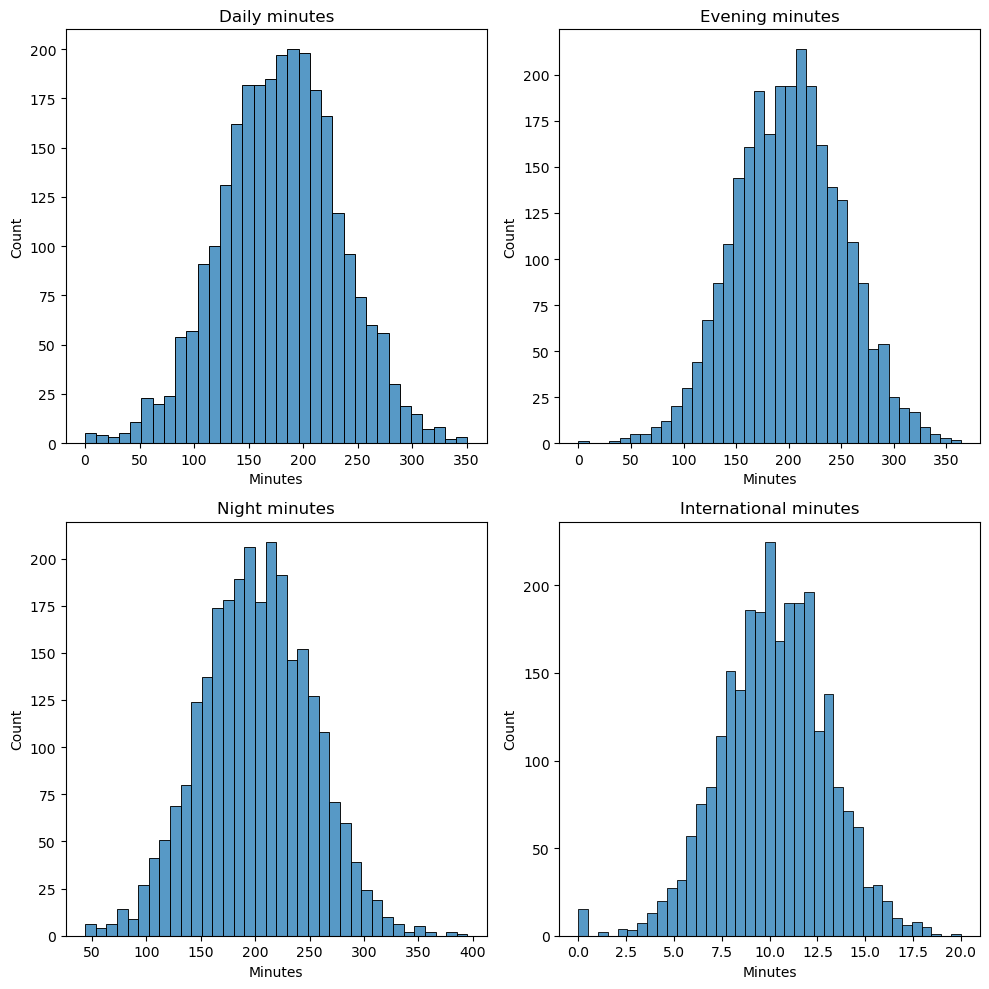

In [16]:
plot_call_minutes(df)

In [17]:
get_minutes_stats(df)

,total_day_minutes,total_eve_minutes,total_night_minutes,total_intl_minutes
Statistic,,,,
Count,"2,666.000","2,666.000","2,666.000","2,666.000"
Missing,0.000,0.000,0.000,0.000
Unique,"1,489.000","1,442.000","1,444.000",158.000
Mean,179.482,200.386,201.169,10.237
Median,179.950,200.900,201.150,10.200
Std. Dev.,54.210,50.952,50.780,2.788
Variance,"2,938.762","2,596.057","2,578.641",7.775
Min,0.000,0.000,43.700,0.000
Q1 (25%),143.400,165.300,166.925,8.500


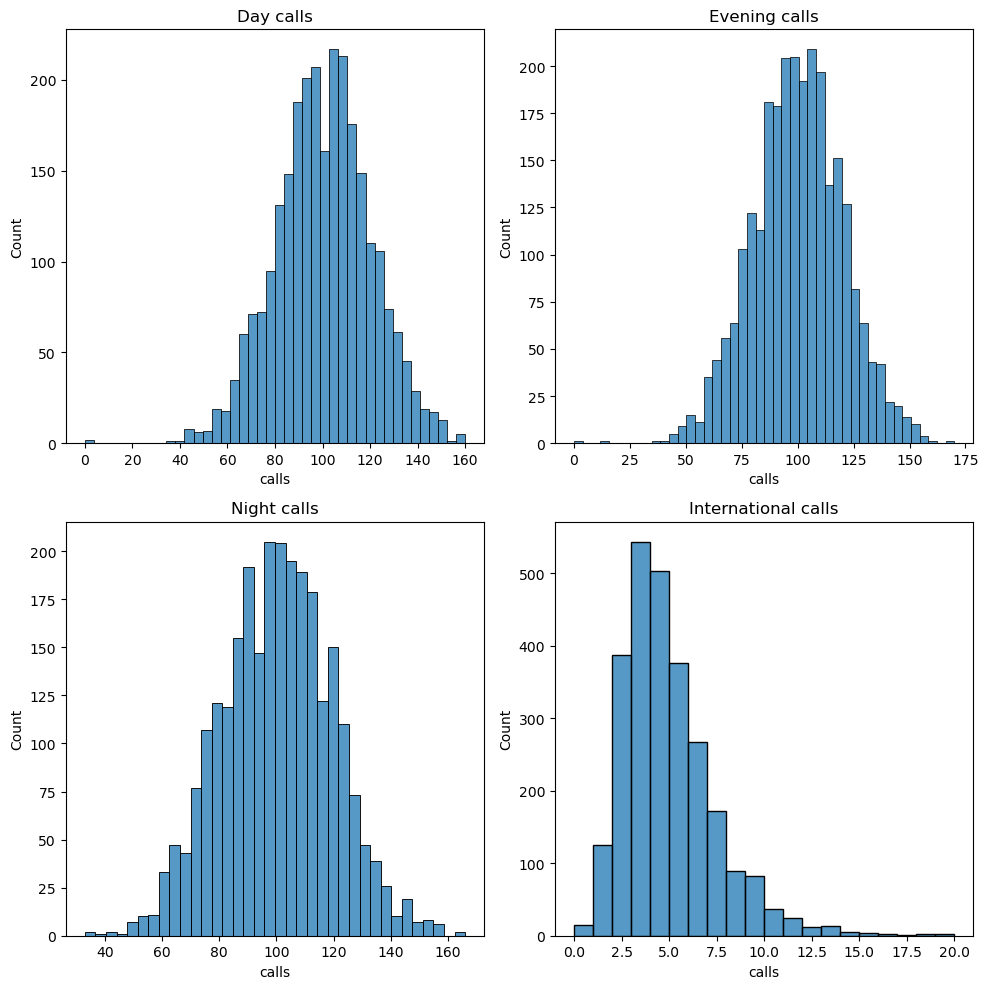

In [18]:
plot_call_counts(df)

In [19]:
get_call_stats(df)

,total_day_calls,total_eve_calls,total_night_calls,total_intl_calls
Statistic,,,,
Count,"2,666.000","2,666.000","2,666.000","2,666.000"
Missing,0.000,0.000,0.000,0.000
Unique,115.000,120.000,118.000,21.000
Mean,100.310,100.024,100.106,4.467
Median,101.000,100.000,100.000,4.000
Std. Dev.,19.988,20.161,19.418,2.456
Variance,399.527,406.484,377.077,6.033
Min,0.000,0.000,33.000,0.000
Q1 (25%),87.000,87.000,87.000,3.000


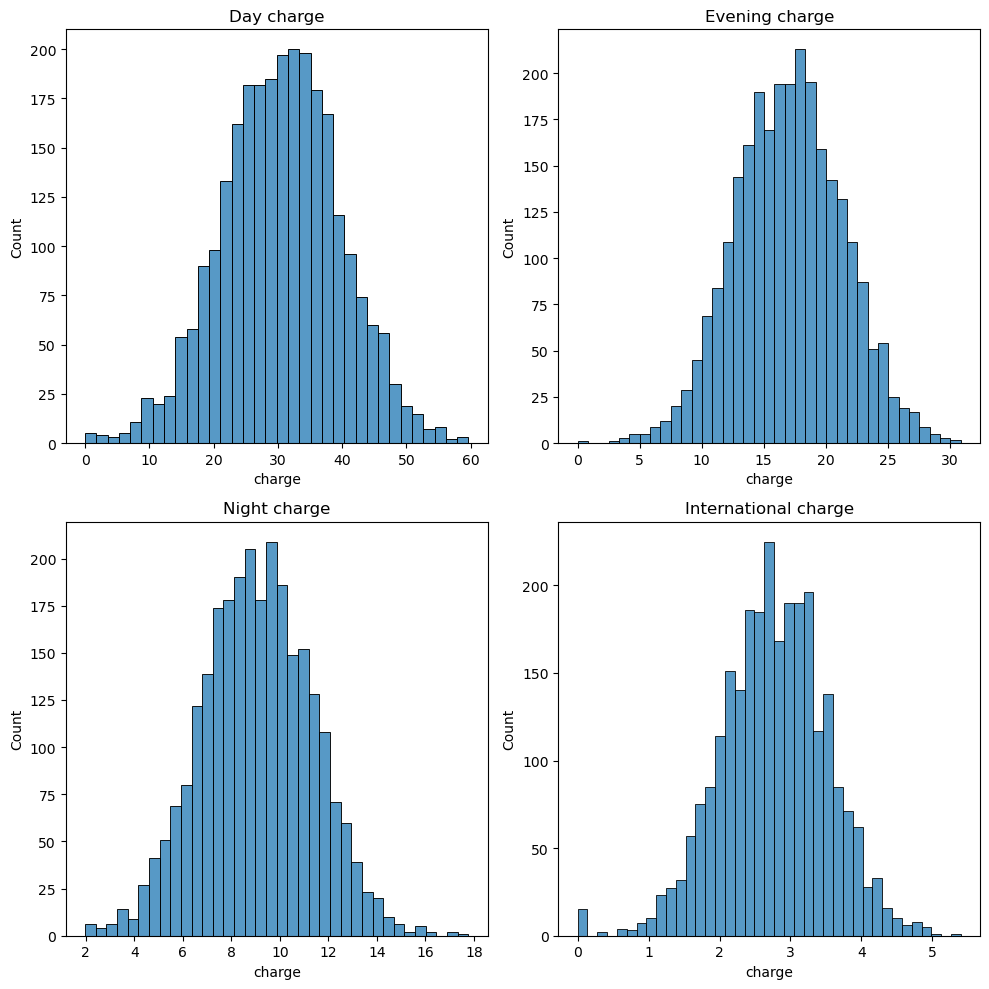

In [20]:
plot_charge_distributions(df)

In [21]:
get_charge_stats(df)

,total_day_charge,total_eve_charge,total_night_charge,total_intl_charge
Statistic,,,,
Count,"2,666.000","2,666.000","2,666.000","2,666.000"
Missing,0.000,0.000,0.000,0.000
Unique,"1,489.000","1,301.000",885.000,158.000
Mean,30.512,17.033,9.053,2.764
Median,30.590,17.080,9.050,2.750
Std. Dev.,9.216,4.331,2.285,0.753
Variance,84.930,18.756,5.222,0.567
Min,0.000,0.000,1.970,0.000
Q1 (25%),24.380,14.050,7.512,2.300


There is a pattern here that when our customer service calls are 0 to 3 calls there is a meaningfull and huge difference in churn rate and many of our customer do not churn, But by looking at the chart below we can see that after that (4 or more calls) about half of the 
customers churn.

**Null hypothesis:** If we have more than 4 calls to customer service then we will have a higher churn rate.

**Alternative hypothesis:** If we have more than 4 calls to customer service then we will have a lower churn rate.

**Business Insight:** Customer service calls are a good indicator of customer satisfaction. If we have more than 4 calls to customer service then we will have a higher churn rate.

**Business Insight:** We may have inefficient customer service that after a customer calls us for more than 4 times we couldn't resolve the issue and the customer churns.

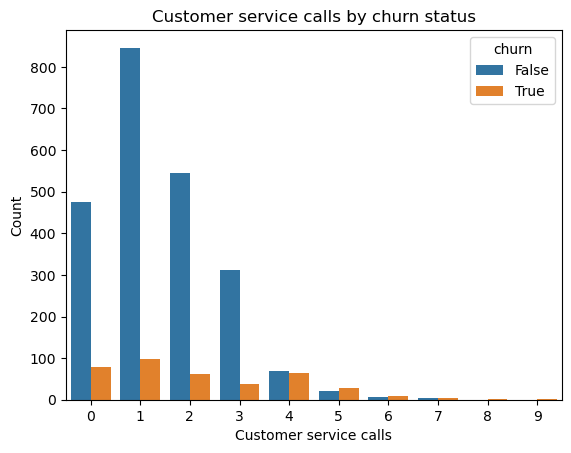

In [22]:
sns.countplot(
    data=df,
    x="customer_service_calls",
    hue="churn",
)

plt.title("Customer service calls by churn status")
plt.xlabel("Customer service calls")
plt.ylabel("Count")

plt.show()

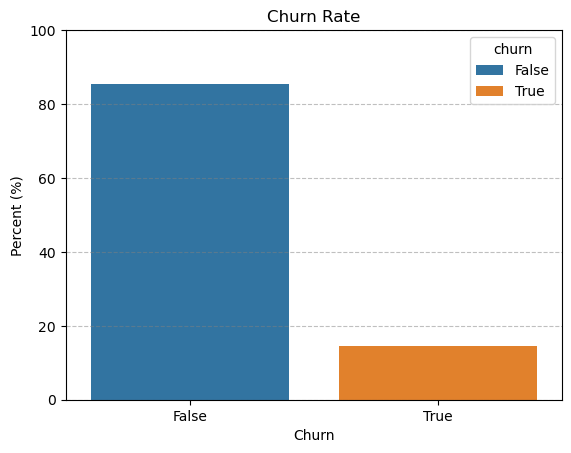

In [23]:
sns.countplot(
    data=df,
    x="churn",
    hue="churn",
    stat="percent",
)

plt.title("Churn Rate")
plt.xlabel("Churn")
plt.ylabel("Percent (%)")
plt.ylim(0, 100)

plt.grid(True, axis="y", linestyle="--", alpha=0.5, color="grey")
plt.show()

## Correlation Analysis

- Using correlation analysis we can find-out that **minutes** features and **charge** features in all four segments **day**, **eve**, **night**, and **intl** are highly correlated, this could be a great insight to drop the charge or minute features from the dataset.

- **voice_mail_plan** and number_vmail_messages are highly correlated with each other, this could be a great insight to randomly drop one of them.

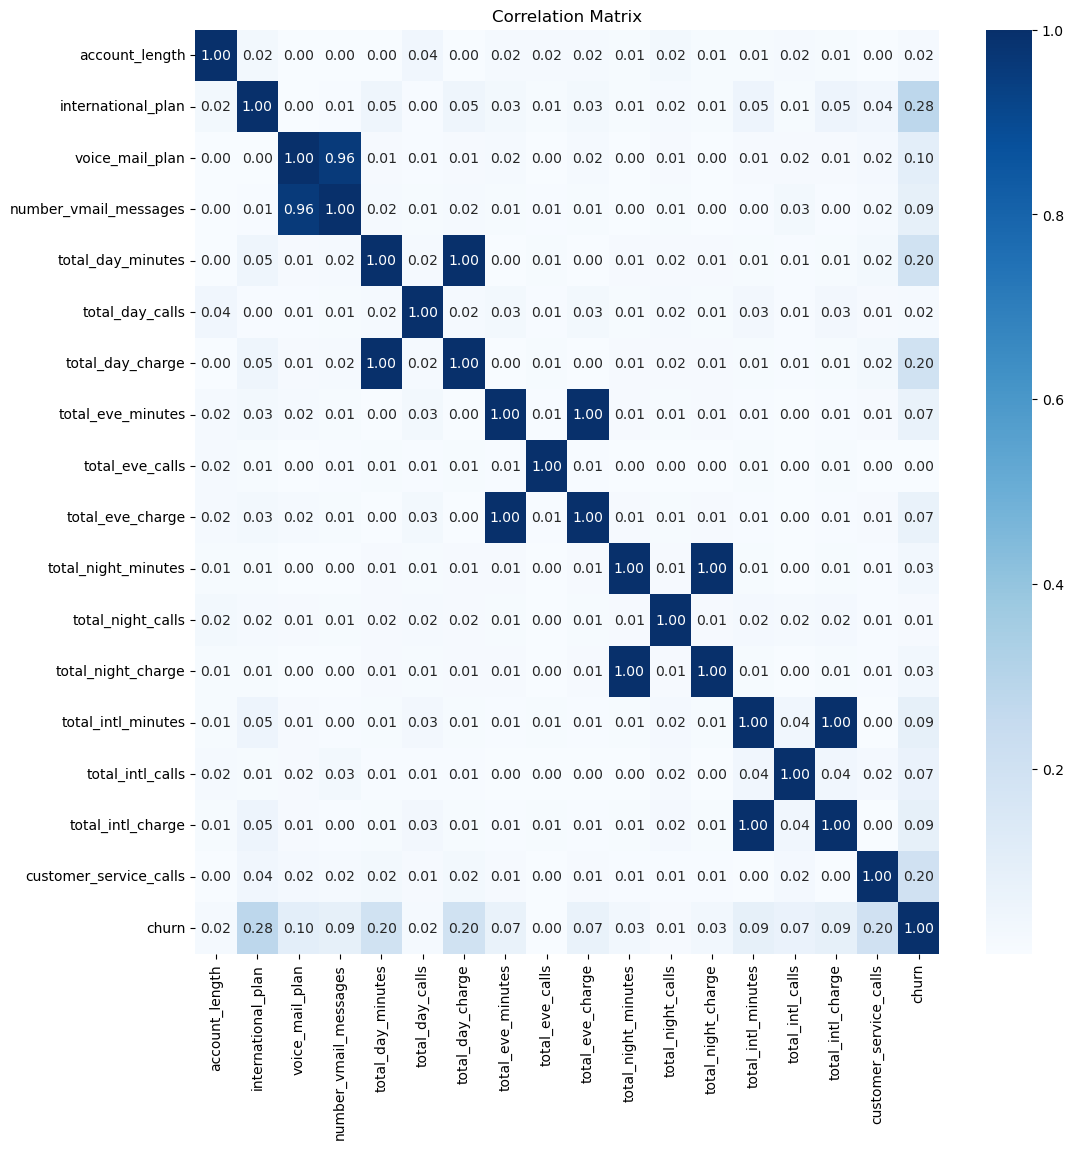

In [24]:
plot_correlation(df)

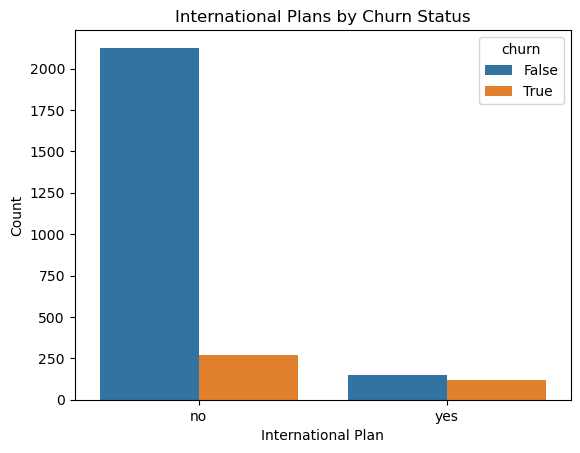

In [25]:
sns.countplot(
    data=df,
    x="international_plan",
    hue="churn",
)

plt.title("International Plans by Churn Status")
plt.ylabel("Count")
plt.xlabel("International Plan")
plt.show()

There is a meaningful difference between mean total_day_minutes for churned customers and mean total_day_minutes for non-churned customers. The customers who used phone to call in the day more are more likely to churn.
There is a high correlation between mean total_day_minutes and total_day_charge. 

**Business Insight:** Maybe there is a problem with the call experience. Customers who call in the day more can be more likely to churn.

**Business Insight:** The strong correlation between mean total_day_minutes and total_day_charge shows suggeest that maybe customers who call more in the day are more likely to churn because the price of their phone bill becomes higher. Maybe it's a good plan to offer a discount to customers who call in the day more than a certain minutes.

In [26]:
describe_total_day_minutes(df)

,total_day_minutes_churned,total_day_minutes_stayed
Statistic,,
Count,388.000,"2,278.000"
Missing,0.000,0.000
Unique,365.000,"1,324.000"
Mean,205.181,175.104
Median,214.950,177.900
Std. Dev.,68.490,50.105
Variance,"4,690.909","2,510.545"
Min,0.000,0.000
Q1 (25%),150.900,142.500


## Overall Churn

1. **What proportion of customers churn, and how severe is the churn problem?**

Abount 14.55% of customers churn, but the average churn rate in the telecom industry is 15-25% in each year so we're are facing a problem but this is not a very severe problem.

2. **How do churned and retained customers differ in their overall usage behavior?**

We can see that churned customers have a higher minutes of day call, and maybe using phone calls in the daytime more is associated with churn.

The churn rate in customers with international plan is much higher than those who don't have international plan.

The churn rate in customers without voice_mail_plan is about 2 times higher than those who have voice_mail_plan.

In [27]:
df['churn'].value_counts() / df.shape[0] * 100

churn
False    85.446362
True     14.553638
Name: count, dtype: float64

about 15% of the customers are churned. The average churn rate in telecomunication industry in this competitive market is about 15-20% each year, so **we're not facing a severe problem**.

Customers with more total_day_minutes and total_day_charge are more likely to churn than those with less total_day_minutes and total_day_charge.

## Customer behavior
1. Does higher daytime usage associate with higher churn?
2. Does international usage associate with higher churn?
3. Does the number of customer-service calls relate to churn risk?
4. Does customer tenure/account length differ between churned and retained customers?

In [28]:
describe_international_calls(df)

,Total International Minutes Churned,Total International Minutes Not Churned
Statistic,,
Count,388.000,"2,278.000"
Missing,0.000,0.000
Unique,111.000,156.000
Mean,10.819,10.138
Median,10.800,10.200
Std. Dev.,2.772,2.780
Variance,7.683,7.726
Min,3.900,0.000
Q1 (25%),8.900,8.400


There is no meaningful association between international usage and churn risk.

In [29]:
df['customer_service_calls'].value_counts()

customer_service_calls
1    945
2    608
0    555
3    348
4    133
5     49
6     17
7      8
9      2
8      1
Name: count, dtype: int64

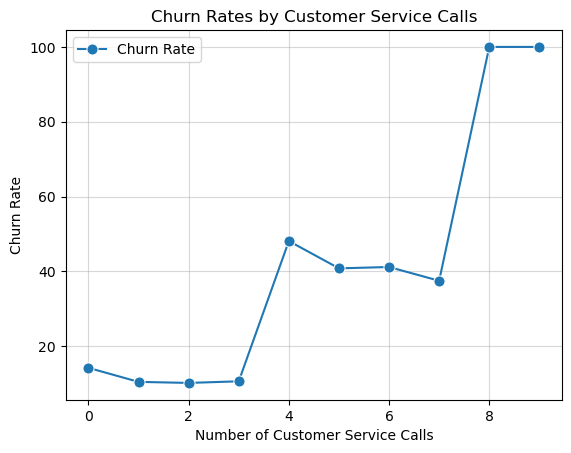

In [30]:
plot_churn_rate_by_customer_service_calls(df)

There is no meaningful difference in Customer account length between the churned customers and the non-churned customers.

In [31]:
get_account_length_info(df)

Account length for churned customers: 102.32 +/- 40.18
Account length for stayed customers: 100.33 +/- 39.46


## Products & services
1. **Do customers with an international plan churn at a different rate than customers without one?**

Yes, they do. Churn rate in customers with international plans is about 90% and in customers without is about 10%. So customer with international plan are 9 times more likely to churn than customers without.

2. **Does having a voicemail plan associate with different churn behavior?**

Yes, having a voicemail plan is associated with a lower churn rate. So customers without a voicemail plan are 2 times more likely to churn than customers with one.

3. **Are customers with high voicemail usage different from low/no voicemail users in terms of churn?**

No, there is no meaningful pattern to suggest that customers with high voicemail usage are more likely to churn than customers with low/no voicemail usage.

In [32]:
def get_intl_churn_rates(df):
	intl_divided_data = get_divided_data(df, "international_plan")
	intl_churn_rates = get_churn_rate(intl_divided_data)
	for value, churn_rate in intl_churn_rates.items():
		print(f"International Plan: {value}, Churn Rate: {churn_rate}%")

get_intl_churn_rates(df)

International Plan: no, Churn Rate: 11.27%
International Plan: yes, Churn Rate: 43.7%


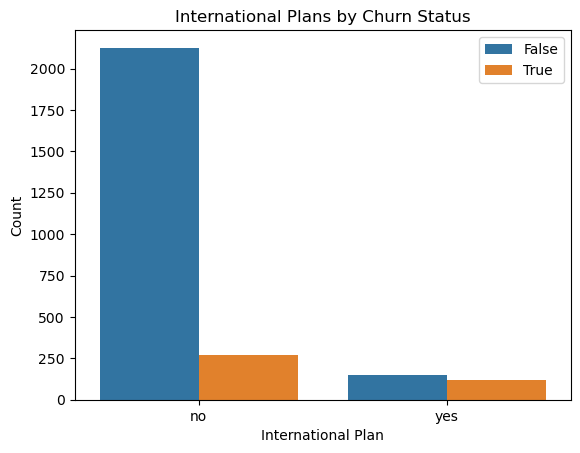

In [33]:
sns.countplot(
    data=df,
    x="international_plan",
    hue="churn",
)

plt.title("International Plans by Churn Status")
plt.xlabel("International Plan")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.show()

In [34]:
def get_vmail_churn_rate(df):
    vmail_divided_data = get_divided_data(df, "voice_mail_plan")
    vmail_churn_rates = get_churn_rate(vmail_divided_data)
    for value, churn_rate in vmail_churn_rates.items():
        print(f"Voice mail plan: {value}, Churn rate: {churn_rate}%")

get_vmail_churn_rate(df)

Voice mail plan: yes, Churn rate: 8.87%
Voice mail plan: no, Churn rate: 16.71%


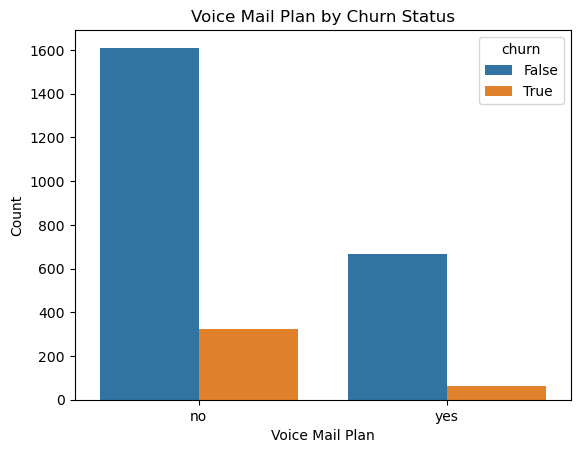

In [35]:
sns.countplot(
    data=df,
    x="voice_mail_plan",
    hue="churn",
)

plt.title("Voice Mail Plan by Churn Status")
plt.xlabel("Voice Mail Plan")
plt.ylabel("Count")
plt.show()

In [36]:
def get_area_code_churn_rate(df):
    area_code_divided_data = get_divided_data(df, "area_code")
    area_code_churn_rates = get_churn_rate(area_code_divided_data)
    for value, churn_rate in area_code_churn_rates.items():
        print(f"Area code: {value}, Churn rate: {churn_rate}%")

get_area_code_churn_rate(df)

Area code: 415, Churn rate: 14.8%
Area code: 408, Churn rate: 14.05%
Area code: 510, Churn rate: 14.58%


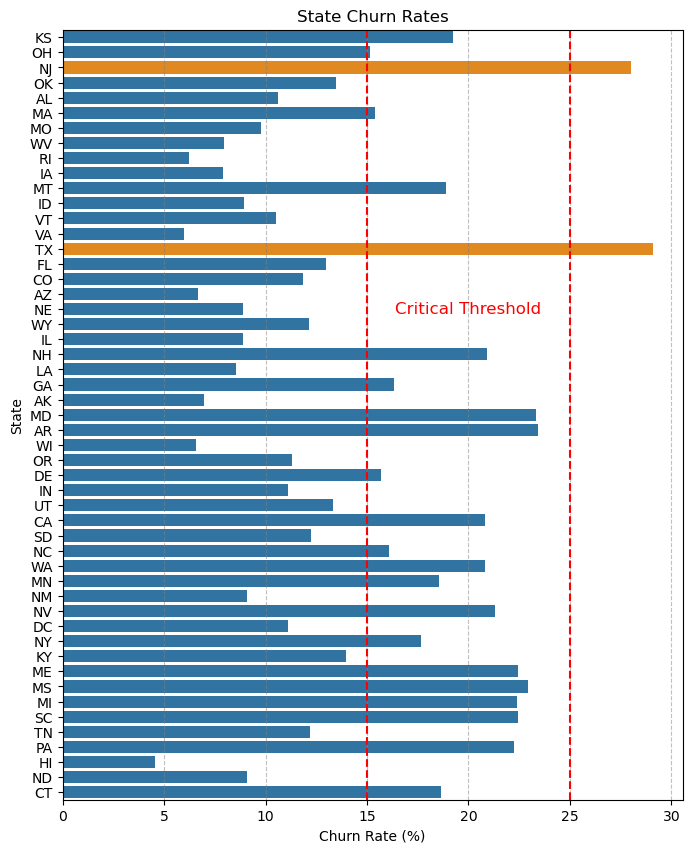

In [37]:
plot_state_churn_rates(df)

In [38]:
def get_cs_calls_churn_rate(df):
    customer_service_calls_divided_data = get_divided_data(df, "customer_service_calls")
    customer_service_calls_churn_rates = get_churn_rate(customer_service_calls_divided_data)
    for value, churn_rate in customer_service_calls_churn_rates.items():
        print(f"Customer service calls: {value}, Churn rate: {churn_rate}%")

get_cs_calls_churn_rate(df)

Customer service calls: 1, Churn rate: 10.48%
Customer service calls: 0, Churn rate: 14.23%
Customer service calls: 2, Churn rate: 10.2%
Customer service calls: 3, Churn rate: 10.63%
Customer service calls: 4, Churn rate: 48.12%
Customer service calls: 5, Churn rate: 40.82%
Customer service calls: 7, Churn rate: 37.5%
Customer service calls: 9, Churn rate: 100%
Customer service calls: 6, Churn rate: 41.18%
Customer service calls: 8, Churn rate: 100%


(0.0, 130.0)

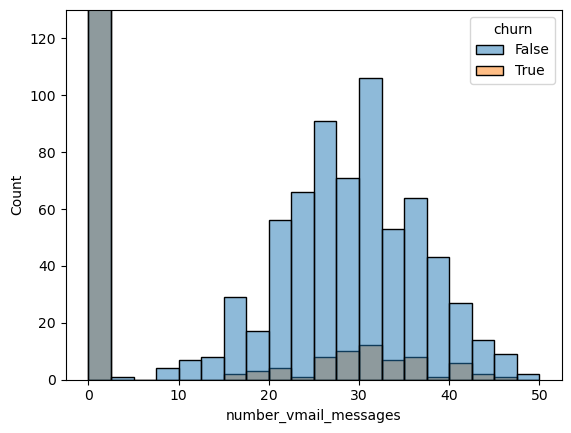

In [39]:
sns.histplot(
    data=df,
    x="number_vmail_messages",
    bins=20,
    hue="churn",
)
plt.ylim(0, 130)

## Customer Report

1. **Is frequent interaction with customer service associated with higher churn?**

There is a pattern here that from 0 to 3 customer-service calls there is no meaningful increase in churn rate, but at 4 we see a significant increase in churn rate and this poit could be used to identify customers who are more likely to churn.

2. **At what level of customer-service calls does churn rate noticeably increase?**

At 4 customer-service calls, the churn rate increases significantly from 10.63 to 48.12%. This could be a strong pattern that customers who are more likely to churn are those who have a high number of customer-service calls.

## Geographic Patterns

1. **Does churn rate vary meaningfully across states?**

The churn rate of **Texas** and **New Jersey** is meaningfully higher than 25% that is a critical threshold for a successful telecom customer retention strategy. These two states may need extensive investigations to understand the root cause of the differences.

2. **Are geographic differences still meaningful after accounting for customer behavior?**

The only slightly meaningful pattern that mentioned earlier too is that the average total_day_minutes in **Texas**  and **New Jersey** is higher than in other states. This is again a sign that there is a need for further investigation and maybe there is something related to the customer behavior that needs to be addressed.

In [57]:
def get_customers_from_tx_and_nj(df):
	df_nj = df.loc[df['state'] == 'NJ']
	df_tx = df.loc[df['state'] == 'TX']
	df = pd.concat([df_nj, df_tx])
	return df

def get_customers_not_in_nj_or_tx(df):
	df_new = df.drop(df.loc[df['state'] == 'NJ'].index)
	df_new = df_new.drop(df_new.loc[df_new['state'] == 'TX'].index)

	return df_new

df_tx_nj = get_customers_from_tx_and_nj(df)
df_not_tx_nj = get_customers_not_in_nj_or_tx(df)

In [70]:
df_tx_nj.describe()

,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,95.523810,7.885714,189.628571,100.342857,32.237429,198.838095,101.314286,16.901429,202.146667,99.809524,9.096762,10.889524,4.752381,2.941143,1.590476
std,39.836467,13.987848,50.261850,17.040014,8.544310,54.316707,19.742727,4.616799,46.781563,19.553229,2.105110,2.466971,2.727287,0.665722,1.472147
min,1.000000,0.000000,84.700000,55.000000,14.400000,49.200000,52.000000,4.180000,57.500000,60.000000,2.590000,3.400000,1.000000,0.920000,0.000000
25%,70.000000,0.000000,155.000000,90.000000,26.350000,160.200000,88.000000,13.620000,175.000000,83.000000,7.880000,9.300000,3.000000,2.510000,1.000000
50%,93.000000,0.000000,189.200000,101.000000,32.160000,197.700000,102.000000,16.800000,197.800000,102.000000,8.900000,10.900000,4.000000,2.940000,1.000000
75%,128.000000,16.000000,224.400000,110.000000,38.150000,232.600000,113.000000,19.770000,236.600000,111.000000,10.650000,12.900000,6.000000,3.480000,2.000000
max,201.000000,43.000000,305.100000,145.000000,51.870000,327.000000,147.000000,27.800000,309.100000,154.000000,13.910000,15.600000,14.000000,4.210000,9.000000


In [71]:
df_not_tx_nj.describe()

,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls
count,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000,2561.000000
mean,100.829364,8.027333,179.065599,100.308864,30.441679,200.449629,99.970715,17.038469,201.128856,100.118313,9.050882,10.210269,4.455681,2.757247,1.561499
std,39.546573,13.599433,54.334814,20.102673,9.236898,50.819065,20.180444,4.319610,50.945624,19.416660,2.292560,2.797921,2.444319,0.755403,1.304524
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,143.100000,87.000000,24.330000,165.300000,87.000000,14.050000,166.800000,87.000000,7.510000,8.400000,3.000000,2.270000,1.000000
50%,101.000000,0.000000,179.400000,101.000000,30.500000,201.000000,100.000000,17.090000,201.200000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,19.000000,215.600000,114.000000,36.650000,235.100000,114.000000,19.980000,236.400000,114.000000,10.640000,12.000000,6.000000,3.240000,2.000000
max,243.000000,50.000000,350.800000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


## Interaction effects

1. **Does the relationship between usage and churn change depending on the customer's plan?**

The pattern that more total_day_minutes is associated with higher churn rates is not consistent across voice_mail_plan.

2. **Are high-usage customers with frequent customer-service calls particularly likely to churn?**



3. Which combinations of customer characteristics are associated with the highest observed churn rates?

In [97]:
df.pivot_table(index='voice_mail_plan', columns='churn', values='total_day_minutes', aggfunc='median')

churn,False,True
voice_mail_plan,,
no,175.90,225.9
yes,183.35,172.1


In [98]:
df.pivot_table(index='international_plan', columns='churn', values='total_day_minutes', aggfunc='median')

churn,False,True
international_plan,,
no,177.45,223.75
yes,180.80,195.20


In [99]:
df.pivot_table(
    index=["churn"],
    columns=['voice_mail_plan'],
    values=["total_day_minutes"],
    aggfunc="mean",
)

total_day_minutes            
voice_mail_plan                no         yes
churn                                        
False                  172.745901  180.788623
True                   210.371827  179.387692

In [115]:
df_high_usage = df.loc[df['total_day_minutes'] > df['total_day_minutes'].mean()]
high_usage_churn_rate= get_churn_rate({"high_usage": df_high_usage})

print(f"Churn rate of high usage customers: {high_usage_churn_rate['high_usage']}%")

Churn rate of high usage customers: 17.25%


In [ ]:
get_divided_data(df_high_usage, based_on="customer_service_calls")